In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
GPU available: False


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

PROJECT_DIR = "/content/drive/MyDrive/WSI_Quality_Control"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project directory created:")
print(PROJECT_DIR)

Project directory created:
/content/drive/MyDrive/WSI_Quality_Control


In [5]:
folders = [
    "data/raw",
    "data/processed",
    "data/annotations",
    "models",
    "outputs/masks",
    "outputs/heatmaps",
    "outputs/reports"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_DIR, folder), exist_ok=True)

print("All folders created successfully!")

All folders created successfully!


In [6]:
!pip install -q openslide-python openslide-bin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 84.8 MB/s eta 0:00:00


In [7]:
import openslide

print("OpenSlide version:", openslide.__version__)
print("OpenSlide is working!")

OpenSlide version: 1.4.6
OpenSlide is working!


In [8]:
!pip install -q opencv-python-headless albumentations matplotlib pandas scikit-learn

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import albumentations as A

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Libraries ready!")

OpenCV: 4.14.0
NumPy: 2.1.3
Libraries ready!


In [11]:
import os

DATA_DIR = os.path.join(PROJECT_DIR, "data", "raw")

os.makedirs(DATA_DIR, exist_ok=True)

print(DATA_DIR)

/content/drive/MyDrive/WSI_Quality_Control/data/raw


In [12]:
!git clone https://github.com/DIAGNijmegen/pathology-artifact-detection.git

Cloning into 'pathology-artifact-detection'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 83 (delta 25), reused 69 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 579.96 KiB | 20.71 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [13]:
!ls pathology-artifact-detection

config	images	LICENSE  README.md  src


In [14]:
!find pathology-artifact-detection -maxdepth 2 -type f | head -30

pathology-artifact-detection/LICENSE
pathology-artifact-detection/README.md
pathology-artifact-detection/.git/index
pathology-artifact-detection/.git/packed-refs
pathology-artifact-detection/.git/description
pathology-artifact-detection/.git/HEAD
pathology-artifact-detection/.git/config
pathology-artifact-detection/images/header.png
pathology-artifact-detection/config/processing.yml
pathology-artifact-detection/config/training.yml
pathology-artifact-detection/src/train.py
pathology-artifact-detection/src/infer.py


In [15]:
import os

DATA_DIR = os.path.join(PROJECT_DIR, "data", "raw")
os.makedirs(DATA_DIR, exist_ok=True)

print(DATA_DIR)

/content/drive/MyDrive/WSI_Quality_Control/data/raw


In [16]:
!git clone https://github.com/DIAGNijmegen/pathology-artifact-detection.git

fatal: destination path 'pathology-artifact-detection' already exists and is not an empty directory.


In [17]:
!ls pathology-artifact-detection

config	images	LICENSE  README.md  src


In [18]:
!cat pathology-artifact-detection/README.md

![artifact-segmentation](https://github.com/DIAGNijmegen/pathology-artifact-detection/blob/main/images/header.png?raw=true)

# Multi-class semantic segmentation of artifacts
Due to the presence of artifacts in digitized histopathology images, tissue regions that are important for diagnosis can be unclear or even completely unusable. As a result, artifacts may interfere with an accurate diagnosis by pathologists or lead to erroneous analyses by deep learning algorithms. By detecting commonly found artifacts, it is possible to improve the process of automated diagnosis. Images with too many artifacts can automatically be rejected by our quality control system, potentially saving many hours of manual inspection.

## Included artifacts
The system detects the following artifact types:
1. Tissue folds
2. Ink
3. Dust
4. Air bubbles 
5. Marker
6. Out-of-focus

## Demo
An interactive demo is accessible via Grand-Challenge:
* URL: [grand-challenge.org/artifact-segmentation](https://grand-challen

In [19]:
!cat pathology-artifact-detection/config/training.yml

---
save_checkpoints: true
checkpoint_name: segmentation_baseline.pth
checkpoint_dir: /.../path/to/checkpoints
plot_dir: /.../path/to/output
data_dir: /.../path/to/data
seed: 1234

architecture: deeplabv3plus
encoder_name: efficientnet-b2
encoder_weights: imagenet
use_batchnorm: true
pooling: avg
dropout: 0.4
device: cuda
workers: 4

loss: dice_loss
loss_weight: 0.8
combine: false
metrics:
  - name: dice_score
    type: segmentation
  - name: dice_loss
    type: segmentation
  - name: dice_score
    type: segmentation
  - name: cross_entropy
    type: classification
  - name: accuracy
    type: classification
rounding: 0.5
ignore_channels: null

lr: 5.0e-4
epochs: 75
batch_size: 40
optimizer: adam
scheduler: cosine
max_round: 75
eta_min: 1.0e-6
step_size: 15
gamma: 0.5

spacing: 4.0
patch_size_train: 320
patch_size_valid: 320
verbose: true
normalize: simple
transform: artifact
eval_dir: /.../path/to/transform
ink_filters: null

classes: 
  - Tissue folds
  - Ink
  - Air bubbles
  - Dus

In [20]:
!cat pathology-artifact-detection/config/processing.yml

# paths to checkpoints and output folder
artifact_network: /.../path/to/checkpoints/artifact_network.pth
tissue_network: /.../path/to/checkpoints/tissue_network.net
output_folder: /.../path/to/inference

# architecure settings
architecture: deeplabv3plus
encoder_name: efficientnet-b2
encoder_weights: imagenet
use_batchnorm: true
pooling: avg
dropout: 0.4
spacing: 4.0

# torch settings
device: cuda
workers: 4

# tissue settings
minimum_region: 5000
minimum_hole: 1000
remove_mask: true

# artifact settings
compute_quality_score: False
overlap: 256
tile_size: 1024
tissue_spacing: 4.0
region_threshold: 10.0
hole_threshold: 200.0
num_classes: 7
input_path: /.../path/to/input/folder/*.tif
mask_path: /.../path/to/tissue-background-masks/folder/{image}_tb_mask.tif


In [23]:
!sed -n '1,260p' pathology-artifact-detection/src/train.py

import os
import yaml
import torch
import shutil
import argparse
import skimage.io
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

from monai.losses import DiceLoss, GeneralizedDiceLoss
from monai.metrics import DiceMetric, compute_roc_auc
from monai.networks.utils import one_hot

from segmentation_models_pytorch import Unet, PSPNet, PAN, DeepLabV3Plus
from segmentation_models_pytorch.utils.metrics import Fscore, IoU, Accuracy

from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torch.optim import Adam, AdamW, RMSprop
from torch.nn import BCELoss

from sklearn.metrics import f1_score

from data import ArtifactDataset, load_train_transform, load_valid_transform
from utils import seed_everything, save_predictions, initialize_wandb
from trainer import Trainer


def main(cfg):
    """Runs main training procedure."""

    # fix random seeds for reproducibility
    seed_everything(seed=cfg['

In [22]:
!sed -n '1,260p' pathology-artifact-detection/src/infer.py

import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import gc
import os
import cv2
import json
import time
import yaml
import torch
import argparse
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import glob

import timm
import torch
import torch.utils.data
import torch.nn.functional as F
import pytorch_lightning as pl

from utils.digitalpathology import filter_regions_array, fill_holes_array

from torch.utils.data import DataLoader
from skimage.util.shape import view_as_windows
from segmentation_models_pytorch import Unet, PSPNet, PAN, DeepLabV3Plus

from utils.wsd_image import ImageReader, ArrayImageWriter

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR


def augment_image(image):
    """Augment the

In [24]:
!sed -n '1,320p' pathology-artifact-detection/src/data.py

sed: can't read pathology-artifact-detection/src/data.py: No such file or directory


In [25]:
!find pathology-artifact-detection -name "data.py"

In [26]:
!git clone https://github.com/DIAGNijmegen/pathology-artifact-detection.git

fatal: destination path 'pathology-artifact-detection' already exists and is not an empty directory.


In [27]:
!ls pathology-artifact-detection

config	images	LICENSE  README.md  src


In [28]:
!find pathology-artifact-detection/src -maxdepth 1 -type f

pathology-artifact-detection/src/train.py
pathology-artifact-detection/src/infer.py


In [29]:
import os

PROJECT_DIR = "/content/WSI_Artifact_Detection"

folders = [
    "data/raw",
    "data/patches/images",
    "data/patches/masks",
    "data/train",
    "data/val",
    "data/test",
    "models",
    "outputs",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_DIR, folder), exist_ok=True)

print("Project structure created!")

Project structure created!


In [30]:
!find /content/WSI_Artifact_Detection -maxdepth 3 -type d

/content/WSI_Artifact_Detection
/content/WSI_Artifact_Detection/models
/content/WSI_Artifact_Detection/outputs
/content/WSI_Artifact_Detection/notebooks
/content/WSI_Artifact_Detection/data
/content/WSI_Artifact_Detection/data/raw
/content/WSI_Artifact_Detection/data/patches
/content/WSI_Artifact_Detection/data/patches/masks
/content/WSI_Artifact_Detection/data/patches/images
/content/WSI_Artifact_Detection/data/train
/content/WSI_Artifact_Detection/data/test
/content/WSI_Artifact_Detection/data/val


In [31]:
!pip install -q segmentation-models-pytorch monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 16.3 MB/s eta 0:00:00


In [32]:
import segmentation_models_pytorch as smp
import torch

print("SMP:", smp.__version__)
print("GPU:", torch.cuda.get_device_name(0))

SMP: 0.5.0


AssertionError: Torch not compiled with CUDA enabled

In [33]:
import segmentation_models_pytorch as smp
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=7
)

model = model.to(DEVICE)

print("Model created successfully!")
print("Device:", DEVICE)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Model created successfully!
Device: cpu


In [34]:
dummy_image = torch.randn(
    2,          # batch size
    3,          # RGB
    320,        # height
    320         # width
).to(DEVICE)

with torch.no_grad():
    output = model(dummy_image)

print("Input shape :", dummy_image.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([2, 3, 320, 320])
Output shape: torch.Size([2, 7, 320, 320])


In [35]:
!find /content/WSI_Artifact_Detection/data -type f | head -30

In [36]:
!find pathology-artifact-detection/images -type f

pathology-artifact-detection/images/header.png


In [37]:
!du -sh pathology-artifact-detection

1.5M	pathology-artifact-detection


In [38]:
!mkdir -p /content/WSI_Artifact_Detection/data/monuseg

In [39]:
import requests

url = "https://monuseg.grand-challenge.org/Data/"

response = requests.get(url)

print("Status:", response.status_code)
print("Page length:", len(response.text))

Status: 200
Page length: 26478


In [40]:
from bs4 import BeautifulSoup
import requests

url = "https://monuseg.grand-challenge.org/Data/"
html = requests.get(url).text

soup = BeautifulSoup(html, "html.parser")

for link in soup.find_all("a"):
    text = link.get_text(" ", strip=True)
    href = link.get("href")

    if href and ("Training" in text or "training" in text or "MoNuSeg" in text):
        print(text)
        print(href)
        print("-" * 80)

MoNuSeg
https://monuseg.grand-challenge.org/
--------------------------------------------------------------------------------
MoNuSeg 2018 Training data
https://drive.google.com/file/d/1ZgqFJomqQGNnsx7w7QBzQQMVA16lbVCA/view?usp=sharing
--------------------------------------------------------------------------------
Training data organ
  information
https://drive.google.com/file/d/1xYyQ31CHFRnvTCTuuHdconlJCMk2SK7Z/view?usp=sharing
--------------------------------------------------------------------------------
MoNuSeg 2018 Testing data
https://drive.google.com/file/d/1NKkSQ5T0ZNQ8aUhh0a8Dt2YKYCQXIViw/view?usp=sharing
--------------------------------------------------------------------------------


In [41]:
!pip install -q gdown

In [42]:
import os

os.makedirs("/content/WSI_Artifact_Detection/data/monuseg", exist_ok=True)

!gdown --fuzzy "https://drive.google.com/file/d/1ZggFJomgQGNnsx7WQBZQ0MVA16IbVCA/view?usp=sharing" \
    -O /content/WSI_Artifact_Detection/data/monuseg/monuseg_training.zip

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1ZggFJomgQGNnsx7WQBZQ0MVA16IbVCA

but Gdown can't. Please check connections and permissions.


In [43]:
!ls -lh /content/WSI_Artifact_Detection/data/monuseg/

total 0


In [44]:
!pip install -q datasets

In [45]:
from datasets import load_dataset

dataset = load_dataset(
    "RationAI/MoNuSeg",
    split="train"
)

print(dataset)

README.md:   0%|          | 0.00/5.21k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 71.1MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 25.8MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/37 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14 [00:00<?, ? examples/s]

Dataset({
    features: ['patient', 'image', 'instances', 'tissue'],
    num_rows: 37
})


In [46]:
small_dataset = dataset.select(range(5))

print("Images:", len(small_dataset))

Images: 5


In [47]:

sample = small_dataset[0]

print("Patient:", sample["patient"])
print("Tissue:", sample["tissue"])
print("Image size:", sample["image"].size)
print("Number of nuclei:", len(sample["instances"]))

Patient: TCGA-38-6178-01Z-00-DX1
Tissue: 3
Image size: (1000, 1000)
Number of nuclei: 424


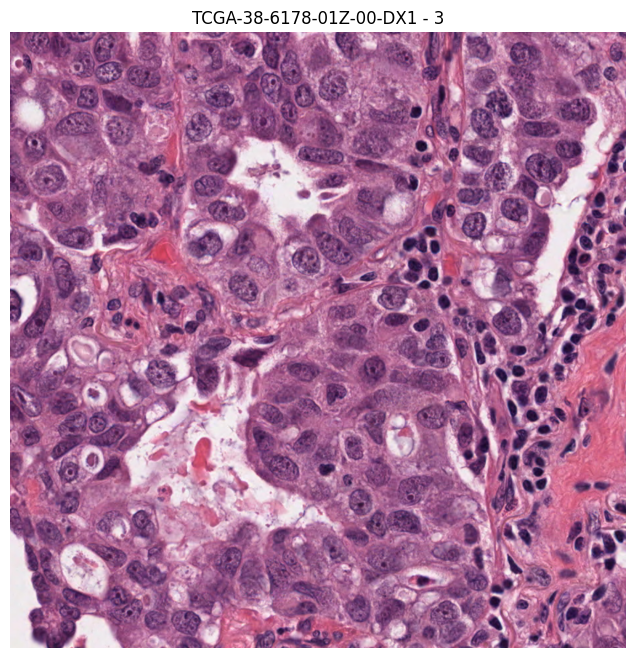

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(sample["image"])
plt.axis("off")
plt.title(
    f'{sample["patient"]} - {sample["tissue"]}'
)
plt.show()

In [50]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def add_ink_artifact(image, seed=42):
    """
    Add a synthetic ink artifact to an H&E pathology image.

    Returns:
        corrupted_image: RGB image with synthetic ink
        mask: binary mask where 1 = ink
    """

    rng = np.random.default_rng(seed)

    # Convert PIL image to NumPy
    image_np = np.array(image).copy()

    h, w, _ = image_np.shape

    # Create empty mask
    mask = np.zeros((h, w), dtype=np.uint8)

    # Random starting point
    x = rng.integers(int(w * 0.2), int(w * 0.8))
    y = rng.integers(int(h * 0.2), int(h * 0.8))

    # Number of ink strokes
    num_strokes = rng.integers(1, 4)

    for _ in range(num_strokes):

        # Random stroke length
        length = rng.integers(100, 300)

        # Random angle
        angle = rng.uniform(0, 2 * np.pi)

        x2 = int(x + length * np.cos(angle))
        y2 = int(y + length * np.sin(angle))

        # Keep coordinates inside image
        x2 = np.clip(x2, 0, w - 1)
        y2 = np.clip(y2, 0, h - 1)

        # Random thickness
        thickness = int(rng.integers(8, 20))

        # Draw artifact mask
        cv2.line(
            mask,
            (x, y),
            (x2, y2),
            1,
            thickness=thickness
        )

        # Slightly irregular parallel stroke
        if rng.random() > 0.5:
            cv2.line(
                mask,
                (x + 5, y + 5),
                (x2 + 5, y2 + 5),
                1,
                thickness=max(3, thickness // 2)
            )

    # Slight blur to make boundaries less artificial
    mask = cv2.GaussianBlur(mask.astype(np.float32), (7, 7), 0)

    # Convert back to binary
    mask = (mask > 0.15).astype(np.uint8)

    # Create corrupted image
    corrupted = image_np.copy()

    # Ink color: dark blue/purple
    ink_color = np.array([30, 20, 80], dtype=np.uint8)

    # Blend ink into tissue
    alpha = 0.85

    corrupted[mask == 1] = (
        alpha * ink_color +
        (1 - alpha) * corrupted[mask == 1]
    ).astype(np.uint8)

    return corrupted, mask

In [51]:
original_image = sample["image"]

corrupted_image, ink_mask = add_ink_artifact(
    original_image,
    seed=42
)

print("Original shape:", np.array(original_image).shape)
print("Corrupted shape:", corrupted_image.shape)
print("Mask shape:", ink_mask.shape)
print("Artifact pixels:", np.sum(ink_mask))

Original shape: (1000, 1000, 3)
Corrupted shape: (1000, 1000, 3)
Mask shape: (1000, 1000)
Artifact pixels: 7778


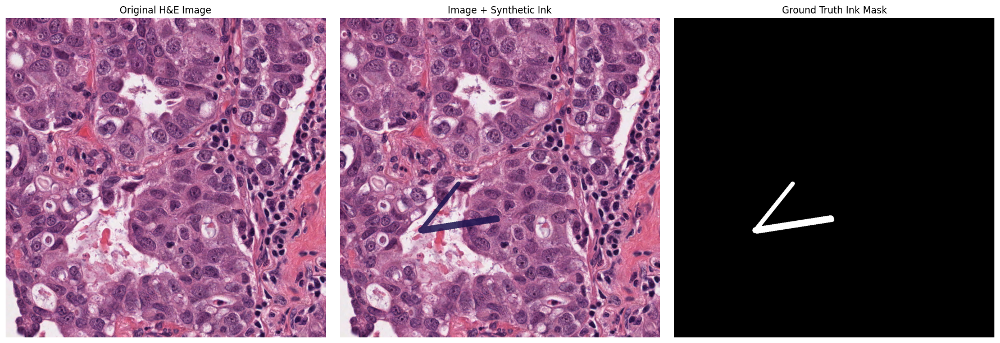

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
axes[0].imshow(original_image)
axes[0].set_title("Original H&E Image")
axes[0].axis("off")

# Synthetic artifact
axes[1].imshow(corrupted_image)
axes[1].set_title("Image + Synthetic Ink")
axes[1].axis("off")

# Ground truth
axes[2].imshow(ink_mask, cmap="gray")
axes[2].set_title("Ground Truth Ink Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [53]:
def add_dust_artifact(image, seed=42):
    rng = np.random.default_rng(seed)

    image_np = np.array(image).copy()
    h, w, _ = image_np.shape

    mask = np.zeros((h, w), dtype=np.uint8)

    # Number of dust particles
    num_particles = rng.integers(30, 80)

    for _ in range(num_particles):

        x = rng.integers(0, w)
        y = rng.integers(0, h)

        radius = rng.integers(2, 7)

        cv2.circle(
            mask,
            (x, y),
            radius,
            1,
            -1
        )

    # Slightly blur edges
    mask_blur = cv2.GaussianBlur(
        mask.astype(np.float32),
        (5, 5),
        0
    )

    mask = (mask_blur > 0.2).astype(np.uint8)

    # Dark gray/black dust
    dust_color = np.array([40, 40, 40], dtype=np.uint8)

    corrupted = image_np.copy()

    alpha = 0.75

    corrupted[mask == 1] = (
        alpha * dust_color +
        (1 - alpha) * corrupted[mask == 1]
    ).astype(np.uint8)

    return corrupted, mask

In [54]:
dust_image, dust_mask = add_dust_artifact(
    original_image,
    seed=42
)

print("Dust pixels:", np.sum(dust_mask))

Dust pixels: 2898


In [55]:
def add_air_bubble_artifact(image, seed=42):

    rng = np.random.default_rng(seed)

    image_np = np.array(image).copy()

    h, w, _ = image_np.shape

    mask = np.zeros((h, w), dtype=np.uint8)

    # Generate 2–5 bubbles
    num_bubbles = rng.integers(2, 6)

    for _ in range(num_bubbles):

        x = rng.integers(80, w - 80)
        y = rng.integers(80, h - 80)

        rx = rng.integers(20, 70)
        ry = rng.integers(20, 70)

        angle = rng.integers(0, 180)

        cv2.ellipse(
            mask,
            (x, y),
            (rx, ry),
            angle,
            0,
            360,
            1,
            -1
        )

    # Smooth edges
    mask_blur = cv2.GaussianBlur(
        mask.astype(np.float32),
        (15, 15),
        0
    )

    mask = (mask_blur > 0.15).astype(np.uint8)

    corrupted = image_np.copy()

    # Air bubble is mostly bright/white
    bubble_color = np.array(
        [245, 245, 245],
        dtype=np.uint8
    )

    alpha = 0.90

    corrupted[mask == 1] = (
        alpha * bubble_color +
        (1 - alpha) * corrupted[mask == 1]
    ).astype(np.uint8)

    return corrupted, mask

In [56]:
bubble_image, bubble_mask = add_air_bubble_artifact(
    original_image,
    seed=42
)

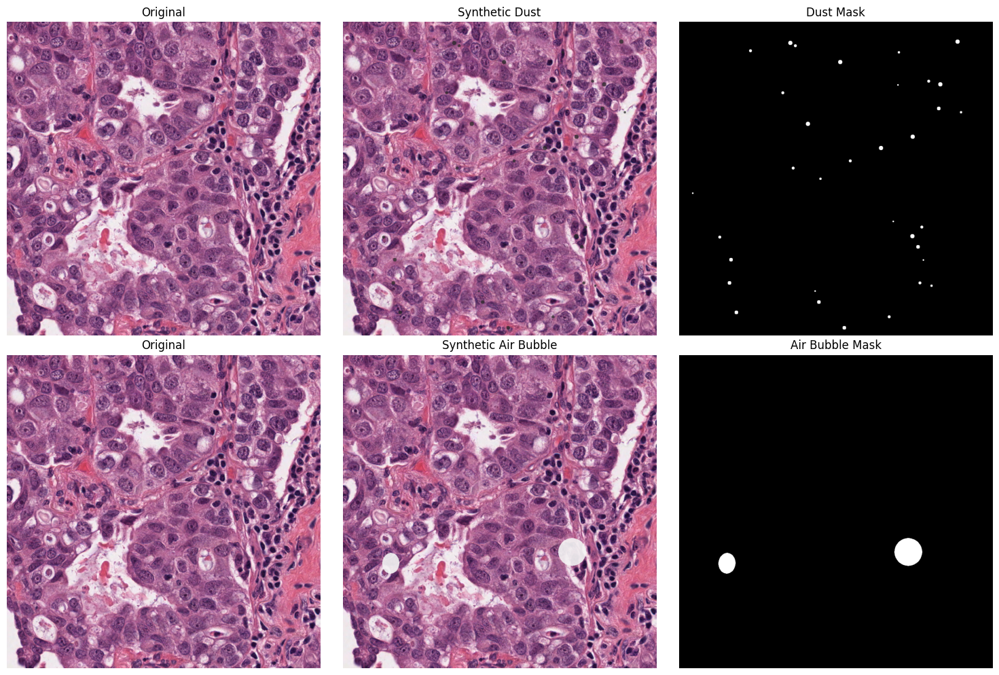

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Dust
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original")

axes[0, 1].imshow(dust_image)
axes[0, 1].set_title("Synthetic Dust")

axes[0, 2].imshow(dust_mask, cmap="gray")
axes[0, 2].set_title("Dust Mask")

# Air bubble
axes[1, 0].imshow(original_image)
axes[1, 0].set_title("Original")

axes[1, 1].imshow(bubble_image)
axes[1, 1].set_title("Synthetic Air Bubble")

axes[1, 2].imshow(bubble_mask, cmap="gray")
axes[1, 2].set_title("Air Bubble Mask")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [58]:
def add_tissue_fold_artifact(image, seed=42):

    rng = np.random.default_rng(seed)

    image_np = np.array(image).copy()
    h, w, _ = image_np.shape

    mask = np.zeros((h, w), dtype=np.uint8)

    # Starting point
    x = rng.integers(int(w * 0.2), int(w * 0.8))
    y = rng.integers(int(h * 0.2), int(h * 0.8))

    # Create a curved fold using connected line segments
    points = [(x, y)]

    for _ in range(rng.integers(3, 6)):
        x += rng.integers(-80, 81)
        y += rng.integers(-80, 81)

        x = np.clip(x, 0, w - 1)
        y = np.clip(y, 0, h - 1)

        points.append((x, y))

    points = np.array(points, dtype=np.int32)

    # Draw thick fold
    cv2.polylines(
        mask,
        [points],
        isClosed=False,
        color=1,
        thickness=rng.integers(25, 50)
    )

    # Smooth boundary
    mask = cv2.GaussianBlur(
        mask.astype(np.float32),
        (11, 11),
        0
    )

    mask = (mask > 0.15).astype(np.uint8)

    corrupted = image_np.copy()

    # Slightly darker reddish/purple fold
    fold_color = np.array([100, 45, 80], dtype=np.uint8)

    alpha = 0.65

    corrupted[mask == 1] = (
        alpha * fold_color +
        (1 - alpha) * corrupted[mask == 1]
    ).astype(np.uint8)

    return corrupted, mask

In [59]:
fold_image, fold_mask = add_tissue_fold_artifact(
    original_image,
    seed=10
)

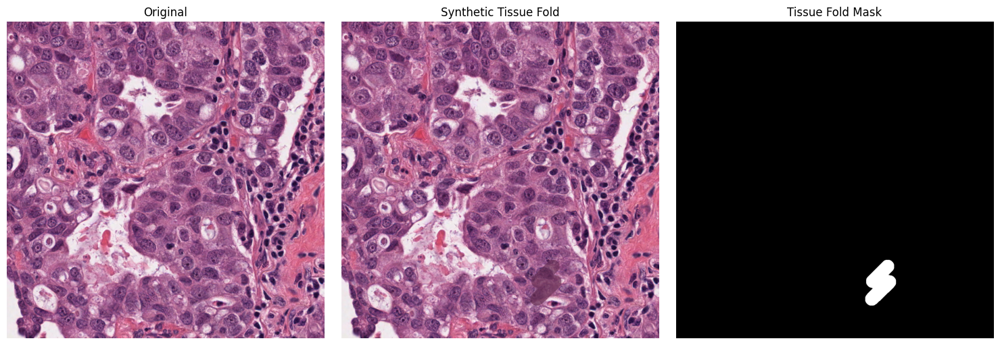

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_image)
axes[0].set_title("Original")

axes[1].imshow(fold_image)
axes[1].set_title("Synthetic Tissue Fold")

axes[2].imshow(fold_mask, cmap="gray")
axes[2].set_title("Tissue Fold Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [61]:
def add_marker_artifact(image, seed=42):

    rng = np.random.default_rng(seed)

    image_np = np.array(image).copy()
    h, w, _ = image_np.shape

    mask = np.zeros((h, w), dtype=np.uint8)

    # Marker position
    x = rng.integers(int(w * 0.15), int(w * 0.85))
    y = rng.integers(int(h * 0.15), int(h * 0.85))

    # Random marker dimensions
    width = rng.integers(80, 180)
    height = rng.integers(30, 80)

    cv2.ellipse(
        mask,
        (x, y),
        (width, height),
        rng.integers(0, 180),
        0,
        360,
        1,
        -1
    )

    mask = cv2.GaussianBlur(
        mask.astype(np.float32),
        (9, 9),
        0
    )

    mask = (mask > 0.2).astype(np.uint8)

    corrupted = image_np.copy()

    # Blue/green marker
    marker_color = np.array(
        [20, 80, 180],
        dtype=np.uint8
    )

    alpha = 0.80

    corrupted[mask == 1] = (
        alpha * marker_color +
        (1 - alpha) * corrupted[mask == 1]
    ).astype(np.uint8)

    return corrupted, mask

In [62]:
marker_image, marker_mask = add_marker_artifact(
    original_image,
    seed=20
)

In [63]:
def add_out_of_focus_artifact(image, seed=42):

    rng = np.random.default_rng(seed)

    image_np = np.array(image).copy()

    h, w, _ = image_np.shape

    mask = np.zeros((h, w), dtype=np.uint8)

    # Random region
    x = rng.integers(int(w * 0.2), int(w * 0.8))
    y = rng.integers(int(h * 0.2), int(h * 0.8))

    rx = rng.integers(80, 180)
    ry = rng.integers(80, 180)

    cv2.ellipse(
        mask,
        (x, y),
        (rx, ry),
        rng.integers(0, 180),
        0,
        360,
        1,
        -1
    )

    # Smooth boundary
    mask = cv2.GaussianBlur(
        mask.astype(np.float32),
        (21, 21),
        0
    )

    mask = (mask > 0.15).astype(np.uint8)

    # Blur entire image
    blurred = cv2.GaussianBlur(
        image_np,
        (31, 31),
        0
    )

    corrupted = image_np.copy()

    corrupted[mask == 1] = blurred[mask == 1]

    return corrupted, mask

In [64]:
blur_image, blur_mask = add_out_of_focus_artifact(
    original_image,
    seed=30
)

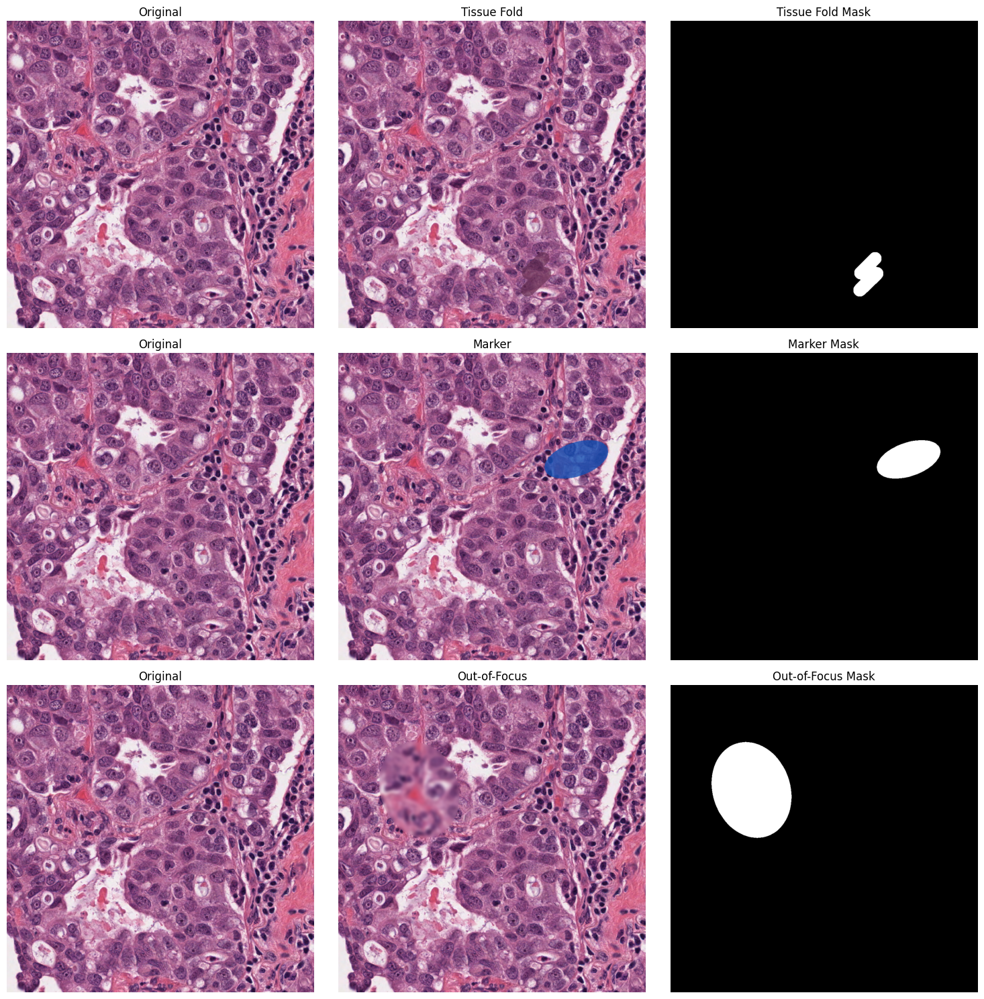

In [65]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

artifacts = [
    ("Tissue Fold", fold_image, fold_mask),
    ("Marker", marker_image, marker_mask),
    ("Out-of-Focus", blur_image, blur_mask)
]

for row, (name, img, mask) in enumerate(artifacts):

    axes[row, 0].imshow(original_image)
    axes[row, 0].set_title("Original")

    axes[row, 1].imshow(img)
    axes[row, 1].set_title(name)

    axes[row, 2].imshow(mask, cmap="gray")
    axes[row, 2].set_title(f"{name} Mask")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [66]:
import os

BASE = "/content/WSI_Artifact_Detection"

dirs = [
    f"{BASE}/data/patches/images",
    f"{BASE}/data/patches/masks",
    f"{BASE}/data/train/images",
    f"{BASE}/data/train/masks",
    f"{BASE}/data/val/images",
    f"{BASE}/data/val/masks",
    f"{BASE}/data/test/images",
    f"{BASE}/data/test/masks"
]

for d in dirs:
    os.makedirs(d, exist_ok=True)

print("Dataset directories created!")

Dataset directories created!


In [67]:
ARTIFACT_CLASSES = {
    "tissue_fold": 1,
    "ink": 2,
    "air_bubble": 3,
    "dust": 4,
    "marker": 5,
    "out_of_focus": 6
}

print(ARTIFACT_CLASSES)

{'tissue_fold': 1, 'ink': 2, 'air_bubble': 3, 'dust': 4, 'marker': 5, 'out_of_focus': 6}


In [68]:
def create_synthetic_sample(image, seed=None):

    rng = np.random.default_rng(seed)

    artifact_name = rng.choice([
        "tissue_fold",
        "ink",
        "air_bubble",
        "dust",
        "marker",
        "out_of_focus"
    ])

    if artifact_name == "tissue_fold":
        corrupted, binary_mask = add_tissue_fold_artifact(
            image, seed
        )

    elif artifact_name == "ink":
        corrupted, binary_mask = add_ink_artifact(
            image, seed
        )

    elif artifact_name == "air_bubble":
        corrupted, binary_mask = add_air_bubble_artifact(
            image, seed
        )

    elif artifact_name == "dust":
        corrupted, binary_mask = add_dust_artifact(
            image, seed
        )

    elif artifact_name == "marker":
        corrupted, binary_mask = add_marker_artifact(
            image, seed
        )

    elif artifact_name == "out_of_focus":
        corrupted, binary_mask = add_out_of_focus_artifact(
            image, seed
        )

    # Convert binary mask to class ID
    class_mask = (
        binary_mask * ARTIFACT_CLASSES[artifact_name]
    ).astype(np.uint8)

    return corrupted, class_mask, artifact_name

In [69]:
test_image, test_mask, artifact_name = create_synthetic_sample(
    original_image,
    seed=100
)

print("Artifact:", artifact_name)
print("Image:", test_image.shape)
print("Mask:", test_mask.shape)
print("Unique mask values:", np.unique(test_mask))

Artifact: marker
Image: (1000, 1000, 3)
Mask: (1000, 1000)
Unique mask values: [0 5]


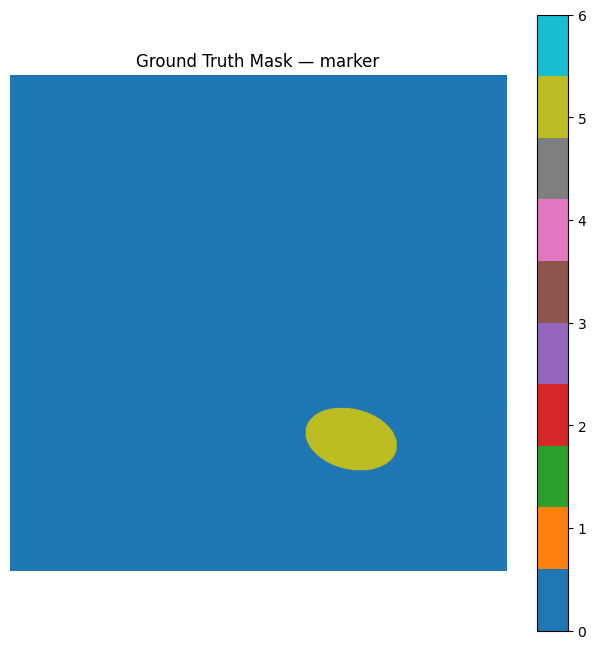

In [70]:
plt.figure(figsize=(8, 8))

plt.imshow(test_mask, cmap="tab10", vmin=0, vmax=6)

plt.title(
    f"Ground Truth Mask — {artifact_name}"
)

plt.colorbar()

plt.axis("off")

plt.show()

In [71]:
print("Artifact:", artifact_name)
print("Unique mask values:", np.unique(test_mask))

Artifact: marker
Unique mask values: [0 5]


In [72]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

BASE = "/content/WSI_Artifact_Detection"

IMAGE_DIR = f"{BASE}/data/patches/images"
MASK_DIR = f"{BASE}/data/patches/masks"

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

PATCH_SIZE = 320
NUM_SAMPLES = 100

In [73]:
for i in tqdm(range(NUM_SAMPLES)):

    # Generate synthetic artifact
    synthetic_image, class_mask, artifact_name = create_synthetic_sample(
        original_image,
        seed=i
    )

    # Resize to model input size
    synthetic_image = cv2.resize(
        synthetic_image,
        (PATCH_SIZE, PATCH_SIZE),
        interpolation=cv2.INTER_AREA
    )

    class_mask = cv2.resize(
        class_mask,
        (PATCH_SIZE, PATCH_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    # Save
    image_path = f"{IMAGE_DIR}/image_{i:04d}.png"
    mask_path = f"{MASK_DIR}/mask_{i:04d}.png"

    cv2.imwrite(
        image_path,
        cv2.cvtColor(synthetic_image, cv2.COLOR_RGB2BGR)
    )

    cv2.imwrite(
        mask_path,
        class_mask

    )

print("Dataset generation completed!")

100%|██████████| 100/100 [00:02<00:00, 33.69it/s]

Dataset generation completed!


In [74]:
print(
    "Images:",
    len(os.listdir(IMAGE_DIR))
)

print(
    "Masks:",
    len(os.listdir(MASK_DIR))
)

Images: 100
Masks: 100


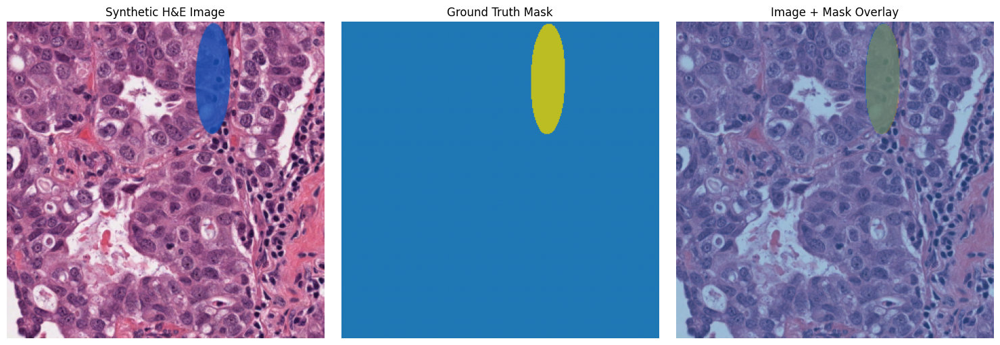

Unique classes: [0 5]


In [75]:
import random

idx = random.randint(0, NUM_SAMPLES - 1)

image_path = f"{IMAGE_DIR}/image_{idx:04d}.png"
mask_path = f"{MASK_DIR}/mask_{idx:04d}.png"

img = cv2.cvtColor(
    cv2.imread(image_path),
    cv2.COLOR_BGR2RGB
)

mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

axes[0].imshow(img)
axes[0].set_title("Synthetic H&E Image")

axes[1].imshow(mask, cmap="tab10", vmin=0, vmax=6)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(img)
axes[2].imshow(
    mask,
    cmap="tab10",
    alpha=0.4,
    vmin=0,
    vmax=6
)
axes[2].set_title("Image + Mask Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Unique classes:", np.unique(mask))

In [76]:
import os
import shutil
from sklearn.model_selection import train_test_split

BASE = "/content/WSI_Artifact_Detection"

IMAGE_DIR = f"{BASE}/data/patches/images"
MASK_DIR = f"{BASE}/data/patches/masks"

TRAIN_IMG = f"{BASE}/data/train/images"
TRAIN_MASK = f"{BASE}/data/train/masks"

VAL_IMG = f"{BASE}/data/val/images"
VAL_MASK = f"{BASE}/data/val/masks"

TEST_IMG = f"{BASE}/data/test/images"
TEST_MASK = f"{BASE}/data/test/masks"

for folder in [
    TRAIN_IMG, TRAIN_MASK,
    VAL_IMG, VAL_MASK,
    TEST_IMG, TEST_MASK
]:
    os.makedirs(folder, exist_ok=True)

# Get image filenames
images = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".png")
])

# Split
train_files, temp_files = train_test_split(
    images,
    test_size=0.30,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42
)

print("Training:", len(train_files))
print("Validation:", len(val_files))
print("Testing:", len(test_files))

Training: 70
Validation: 15
Testing: 15


In [77]:
def copy_dataset(files, image_destination, mask_destination):

    for filename in files:

        image_source = os.path.join(
            IMAGE_DIR,
            filename
        )

        mask_filename = filename.replace(
            "image_",
            "mask_"
        )

        mask_source = os.path.join(
            MASK_DIR,
            mask_filename
        )

        shutil.copy(
            image_source,
            image_destination
        )

        shutil.copy(
            mask_source,
            mask_destination
        )


copy_dataset(
    train_files,
    TRAIN_IMG,
    TRAIN_MASK
)

copy_dataset(
    val_files,
    VAL_IMG,
    VAL_MASK
)

copy_dataset(
    test_files,
    TEST_IMG,
    TEST_MASK
)

print("Dataset split completed!")

Dataset split completed!


In [78]:
for name, img_dir, mask_dir in [
    ("Train", TRAIN_IMG, TRAIN_MASK),
    ("Validation", VAL_IMG, VAL_MASK),
    ("Test", TEST_IMG, TEST_MASK)
]:

    print(
        name,
        "Images:", len(os.listdir(img_dir)),
        "Masks:", len(os.listdir(mask_dir))
    )

Train Images: 70 Masks: 70
Validation Images: 15 Masks: 15
Test Images: 15 Masks: 15


In [79]:

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os


class ArtifactDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith(".png")
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        mask_name = image_name.replace(
            "image_",
            "mask_"
        )

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        # Read image
        image = Image.open(image_path).convert("RGB")

        # Read mask
        mask = Image.open(mask_path)

        image = np.array(image)
        mask = np.array(mask)

        # Convert image to [C,H,W]
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1)

        # Normalize image
        image = image / 255.0

        # Mask should contain integer class IDs
        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask

In [80]:
train_dataset = ArtifactDataset(
    TRAIN_IMG,
    TRAIN_MASK
)

val_dataset = ArtifactDataset(
    VAL_IMG,
    VAL_MASK
)

test_dataset = ArtifactDataset(
    TEST_IMG,
    TEST_MASK
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 70
Validation: 15
Test: 15


In [82]:
images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

print("Image range:",
      images.min().item(),
      images.max().item())

print("Mask classes:",
      torch.unique(masks))

Image batch shape: torch.Size([4, 3, 320, 320])
Mask batch shape: torch.Size([4, 320, 320])
Image range: 0.027450980618596077 0.9921568632125854
Mask classes: tensor([0, 3, 4])


In [81]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
GPU available: False


In [83]:
import segmentation_models_pytorch as smp
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.DeepLabV3Plus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=7,
    activation=None
)

model = model.to(DEVICE)

print("Model created successfully!")
print("Device:", DEVICE)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 36.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Model created successfully!
Device: cpu


In [84]:
images, masks = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([4, 3, 320, 320])
Output shape: torch.Size([4, 7, 320, 320])


In [85]:
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        num_classes = logits.shape[1]

        probs = torch.softmax(logits, dim=1)

        targets_one_hot = F.one_hot(
            targets,
            num_classes=num_classes
        )

        targets_one_hot = targets_one_hot.permute(
            0, 3, 1, 2
        ).float()

        dims = (0, 2, 3)

        intersection = (
            probs * targets_one_hot
        ).sum(dims)

        denominator = (
            probs + targets_one_hot
        ).sum(dims)

        dice = (
            2 * intersection + self.smooth
        ) / (
            denominator + self.smooth
        )

        return 1 - dice.mean()

In [86]:
dice_loss = DiceLoss()
cross_entropy = nn.CrossEntropyLoss()

In [87]:
def combined_loss(logits, targets):

    ce = cross_entropy(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return 0.5 * ce + 0.5 * dice

In [88]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [89]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10,
    eta_min=1e-6
)

In [90]:
model.train()

images, masks = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

optimizer.zero_grad()

outputs = model(images)

loss = combined_loss(
    outputs,
    masks
)

loss.backward()

optimizer.step()

print("One training step completed!")
print("Loss:", loss.item())

One training step completed!
Loss: 1.4360684156417847


In [91]:
NUM_EPOCHS = 10

best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(
            outputs,
            masks
        )

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = combined_loss(
                outputs,
                masks
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            f"{BASE}/models/best_model.pth"
        )

        print("  → Best model saved!")

Epoch [1/10] Train Loss: 1.3326 | Val Loss: 1.4444
  → Best model saved!
Epoch [2/10] Train Loss: 1.1493 | Val Loss: 1.2800
  → Best model saved!
Epoch [3/10] Train Loss: 0.9749 | Val Loss: 1.0756
  → Best model saved!
Epoch [4/10] Train Loss: 0.8495 | Val Loss: 1.0081
  → Best model saved!
Epoch [5/10] Train Loss: 0.7674 | Val Loss: 0.9317
  → Best model saved!
Epoch [6/10] Train Loss: 0.7164 | Val Loss: 0.8933
  → Best model saved!
Epoch [7/10] Train Loss: 0.6854 | Val Loss: 0.8667
  → Best model saved!
Epoch [8/10] Train Loss: 0.6661 | Val Loss: 0.8566
  → Best model saved!
Epoch [9/10] Train Loss: 0.6556 | Val Loss: 0.8586
Epoch [10/10] Train Loss: 0.6500 | Val Loss: 0.8139
  → Best model saved!


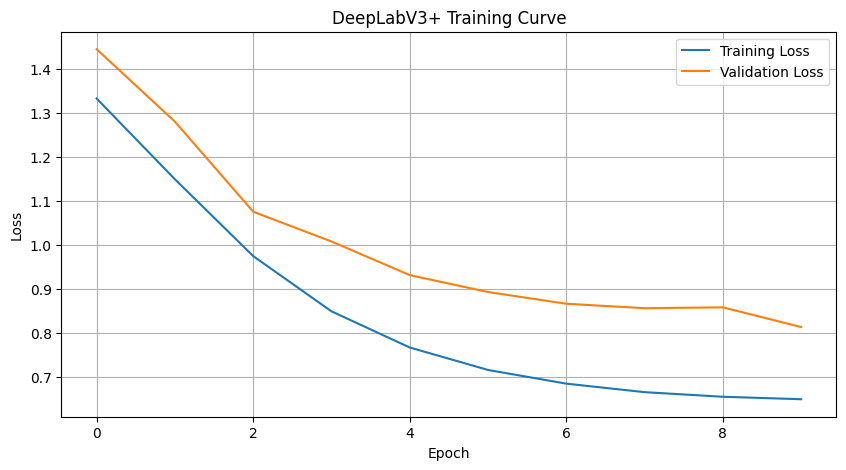

In [92]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DeepLabV3+ Training Curve")

plt.legend()
plt.grid()

plt.show()

In [93]:
model.load_state_dict(
    torch.load(
        f"{BASE}/models/best_model.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


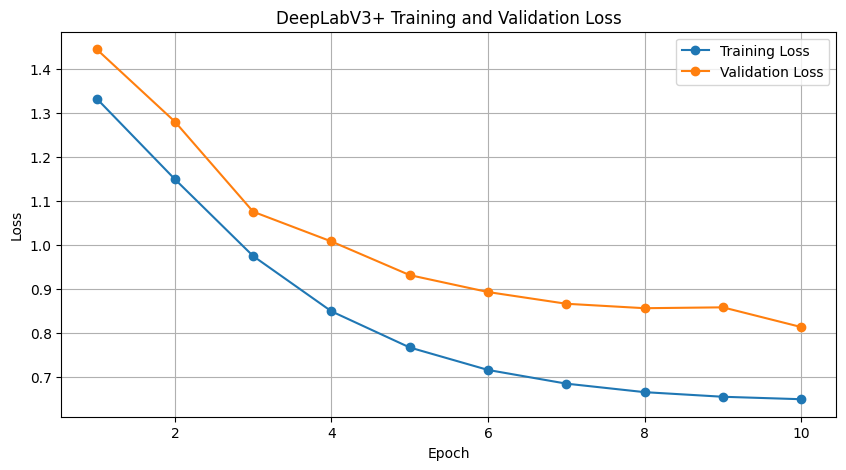

In [94]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DeepLabV3+ Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [95]:
model.load_state_dict(
    torch.load(
        f"{BASE}/models/best_model.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded!")

Best model loaded!


In [96]:
import numpy as np

NUM_CLASSES = 7

class_intersection = np.zeros(NUM_CLASSES)
class_union = np.zeros(NUM_CLASSES)
class_pred = np.zeros(NUM_CLASSES)
class_target = np.zeros(NUM_CLASSES)

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        predictions = predictions.cpu().numpy()
        masks = masks.cpu().numpy()

        for cls in range(NUM_CLASSES):

            pred_cls = predictions == cls
            target_cls = masks == cls

            intersection = np.logical_and(
                pred_cls,
                target_cls
            ).sum()

            union = np.logical_or(
                pred_cls,
                target_cls
            ).sum()

            class_intersection[cls] += intersection
            class_union[cls] += union

            class_pred[cls] += pred_cls.sum()
            class_target[cls] += target_cls.sum()

In [97]:
dice_scores = []
iou_scores = []

for cls in range(NUM_CLASSES):

    intersection = class_intersection[cls]
    union = class_union[cls]

    dice = (
        2 * intersection
        / (
            class_pred[cls]
            + class_target[cls]
            + 1e-8
        )
    )

    iou = (
        intersection
        / (union + 1e-8)
    )

    dice_scores.append(dice)
    iou_scores.append(iou)

In [98]:
class_names = [
    "Background",
    "Tissue Fold",
    "Ink",
    "Air Bubble",
    "Dust",
    "Marker",
    "Out-of-Focus"
]

for i in range(NUM_CLASSES):

    print(
        f"{class_names[i]:15s} "
        f"Dice: {dice_scores[i]:.4f} | "
        f"IoU: {iou_scores[i]:.4f}"
    )

print("\nMean Dice:",
      np.mean(dice_scores[1:]))

print("Mean IoU:",
      np.mean(iou_scores[1:]))

Background      Dice: 0.9888 | IoU: 0.9778
Tissue Fold     Dice: 0.0000 | IoU: 0.0000
Ink             Dice: 0.0000 | IoU: 0.0000
Air Bubble      Dice: 0.0000 | IoU: 0.0000
Dust            Dice: 0.0000 | IoU: 0.0000
Marker          Dice: 0.5471 | IoU: 0.3766
Out-of-Focus    Dice: 0.6682 | IoU: 0.5018

Mean Dice: 0.2025581830621499
Mean IoU: 0.14638971727339714


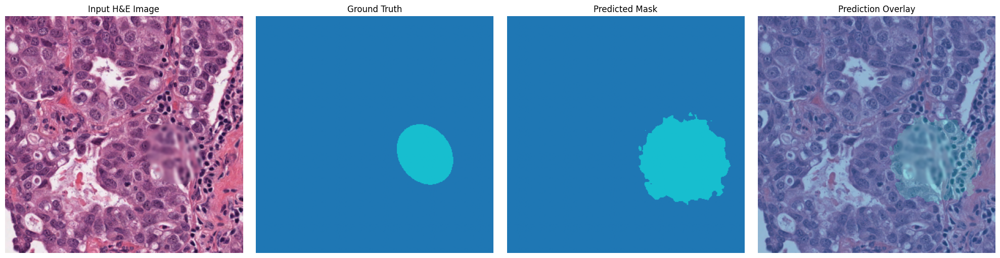

In [99]:
images, masks = next(iter(test_loader))

images_gpu = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images_gpu)

predictions = torch.argmax(
    outputs,
    dim=1
)

image = images[0].permute(1, 2, 0).numpy()
true_mask = masks[0].numpy()
pred_mask = predictions[0].cpu().numpy()

fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 5)
)

axes[0].imshow(image)
axes[0].set_title("Input H&E Image")

axes[1].imshow(
    true_mask,
    cmap="tab10",
    vmin=0,
    vmax=6
)
axes[1].set_title("Ground Truth")

axes[2].imshow(
    pred_mask,
    cmap="tab10",
    vmin=0,
    vmax=6
)
axes[2].set_title("Predicted Mask")

axes[3].imshow(image)
axes[3].imshow(
    pred_mask,
    cmap="tab10",
    alpha=0.45,
    vmin=0,
    vmax=6
)
axes[3].set_title("Prediction Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [100]:
print("Number of source images:", len(small_dataset))

Number of source images: 5


In [101]:
from sklearn.model_selection import train_test_split

NUM_SOURCE_IMAGES = min(20, len(small_dataset))

source_indices = list(range(NUM_SOURCE_IMAGES))

train_idx, temp_idx = train_test_split(
    source_indices,
    test_size=0.30,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42
)

print("Train source images:", len(train_idx))
print("Validation source images:", len(val_idx))
print("Test source images:", len(test_idx))

Train source images: 3
Validation source images: 1
Test source images: 1


In [102]:
import os
import cv2
import random
import numpy as np
from PIL import Image

# --------------------------------------------------
# Synthetic artifact generator
# --------------------------------------------------

CLASS_IDS = {
    "tissue_fold": 1,
    "ink": 2,
    "air_bubble": 3,
    "dust": 4,
    "marker": 5,
    "out_of_focus": 6
}


def generate_artifact(image, artifact_type, seed=None):

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    image = np.array(image.convert("RGB")).copy()

    h, w = image.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    # -------------------------
    # 1. Tissue Fold
    # -------------------------
    if artifact_type == "tissue_fold":

        x1 = random.randint(w // 4, w // 2)
        x2 = random.randint(w // 2, 3 * w // 4)

        points = np.array([
            [x1, 0],
            [x1 + random.randint(20, 50), h],
            [x2 + random.randint(20, 60), h],
            [x2, 0]
        ], dtype=np.int32)

        cv2.fillPoly(mask, [points], CLASS_IDS[artifact_type])

        overlay = image.copy()
        overlay[mask > 0] = [245, 210, 225]

        image = cv2.addWeighted(
            image, 0.65,
            overlay, 0.35,
            0
        )

    # -------------------------
    # 2. Ink
    # -------------------------
    elif artifact_type == "ink":

        num_lines = random.randint(1, 3)

        for _ in range(num_lines):

            x1 = random.randint(0, w - 1)
            y1 = random.randint(0, h - 1)

            x2 = np.clip(
                x1 + random.randint(-100, 100),
                0, w - 1
            )

            y2 = np.clip(
                y1 + random.randint(-100, 100),
                0, h - 1
            )

            thickness = random.randint(5, 12)

            cv2.line(
                mask,
                (x1, y1),
                (x2, y2),
                CLASS_IDS[artifact_type],
                thickness
            )

        image[mask > 0] = [40, 30, 90]

    # -------------------------
    # 3. Air Bubble
    # -------------------------
    elif artifact_type == "air_bubble":

        num_bubbles = random.randint(1, 4)

        for _ in range(num_bubbles):

            cx = random.randint(30, w - 30)
            cy = random.randint(30, h - 30)
            radius = random.randint(10, 30)

            cv2.circle(
                mask,
                (cx, cy),
                radius,
                CLASS_IDS[artifact_type],
                -1
            )

        # white/bright bubbles
        image[mask > 0] = [245, 245, 245]

    # -------------------------
    # 4. Dust
    # -------------------------
    elif artifact_type == "dust":

        num_dust = random.randint(10, 30)

        for _ in range(num_dust):

            cx = random.randint(0, w - 1)
            cy = random.randint(0, h - 1)
            radius = random.randint(1, 4)

            cv2.circle(
                mask,
                (cx, cy),
                radius,
                CLASS_IDS[artifact_type],
                -1
            )

        image[mask > 0] = [30, 30, 30]

    # -------------------------
    # 5. Marker
    # -------------------------
    elif artifact_type == "marker":

        x1 = random.randint(0, w // 2)
        y1 = random.randint(0, h)

        x2 = random.randint(w // 2, w)
        y2 = random.randint(0, h)

        thickness = random.randint(12, 25)

        cv2.line(
            mask,
            (x1, y1),
            (x2, y2),
            CLASS_IDS[artifact_type],
            thickness
        )

        image[mask > 0] = [20, 20, 20]

    # -------------------------
    # 6. Out-of-focus
    # -------------------------
    elif artifact_type == "out_of_focus":

        x1 = random.randint(0, w // 2)
        y1 = random.randint(0, h // 2)

        x2 = random.randint(
            w // 2,
            w
        )

        y2 = random.randint(
            h // 2,
            h
        )

        mask[y1:y2, x1:x2] = CLASS_IDS[artifact_type]

        blurred = cv2.GaussianBlur(
            image,
            (31, 31),
            0
        )

        image[mask > 0] = blurred[mask > 0]

    return image, mask


print("Artifact generator ready!")

Artifact generator ready!


In [103]:
def generate_samples(indices, split_name, samples_per_image=20):

    image_dir = f"{BASE}/data/{split_name}/images"
    mask_dir = f"{BASE}/data/{split_name}/masks"

    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)

    counter = 0

    artifact_types = list(CLASS_IDS.keys())

    for idx in indices:

        sample = small_dataset[idx]

        original_image = sample["image"]

        for j in range(samples_per_image):

            # Randomly select artifact
            artifact_type = random.choice(
                artifact_types
            )

            # Generate artifact
            synthetic_image, mask = generate_artifact(
                original_image,
                artifact_type,
                seed=idx * 1000 + j
            )

            # Resize
            synthetic_image = cv2.resize(
                synthetic_image,
                (320, 320),
                interpolation=cv2.INTER_AREA
            )

            mask = cv2.resize(
                mask,
                (320, 320),
                interpolation=cv2.INTER_NEAREST
            )

            # Save image
            image_path = os.path.join(
                image_dir,
                f"image_{counter:05d}.png"
            )

            # Save mask
            mask_path = os.path.join(
                mask_dir,
                f"mask_{counter:05d}.png"
            )

            cv2.imwrite(
                image_path,
                cv2.cvtColor(
                    synthetic_image,
                    cv2.COLOR_RGB2BGR
                )
            )

            cv2.imwrite(
                mask_path,
                mask
            )

            counter += 1

    print(
        f"{split_name}: generated {counter} samples"
    )

In [104]:
generate_samples(
    train_idx,
    "train",
    samples_per_image=20
)

generate_samples(
    val_idx,
    "val",
    samples_per_image=20
)

generate_samples(
    test_idx,
    "test",
    samples_per_image=20
)

train: generated 60 samples
val: generated 20 samples
test: generated 20 samples


In [105]:
for split in ["train", "val", "test"]:

    image_dir = f"{BASE}/data/{split}/images"
    mask_dir = f"{BASE}/data/{split}/masks"

    print("\n", split.upper())

    print(
        "Images:",
        len(os.listdir(image_dir))
    )

    print(
        "Masks:",
        len(os.listdir(mask_dir))
    )


 TRAIN
Images: 130
Masks: 130

 VAL
Images: 35
Masks: 35

 TEST
Images: 35
Masks: 35


Image: (320, 320, 3)
Mask: (320, 320)
Mask classes: [0 3]


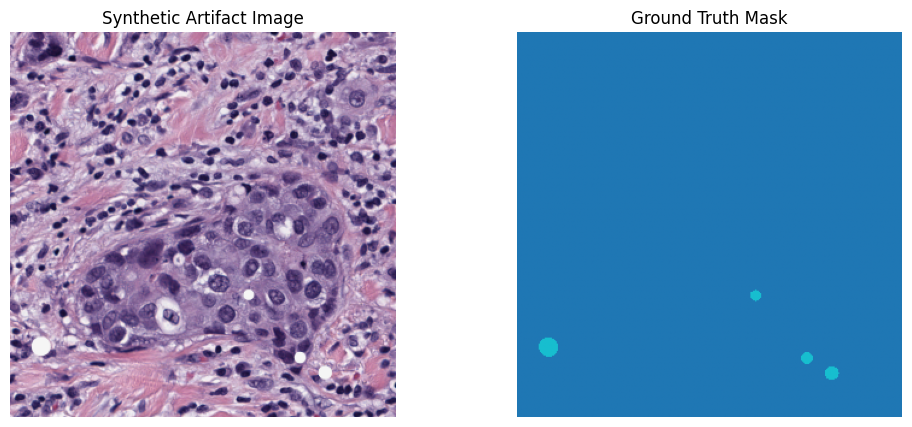

In [106]:
import matplotlib.pyplot as plt
import cv2

image_path = f"{BASE}/data/train/images/image_00000.png"
mask_path = f"{BASE}/data/train/masks/mask_00000.png"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)

print("Image:", image.shape)
print("Mask:", mask.shape)
print("Mask classes:", np.unique(mask))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Synthetic Artifact Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="tab10")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [107]:
import os
import cv2
import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader


class ArtifactDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

        assert len(self.images) == len(self.masks), \
            "Number of images and masks do not match!"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        # -------------------------
        # Read image
        # -------------------------
        image_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # -------------------------
        # Read mask
        # -------------------------
        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        # -------------------------
        # Convert image
        # HWC → CHW
        # -------------------------
        image = image.astype(np.float32) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        image = image.permute(
            2, 0, 1
        )

        # -------------------------
        # Convert mask
        # -------------------------
        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask


print("Dataset class created successfully!")

Dataset class created successfully!


In [108]:
import os
import cv2
import torch
import numpy as np

from torch.utils.data import Dataset, DataLoader


class ArtifactDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

        assert len(self.images) == len(self.masks), \
            "Number of images and masks do not match!"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        # -------------------------
        # Read image
        # -------------------------
        image_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # -------------------------
        # Read mask
        # -------------------------
        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        # -------------------------
        # Convert image
        # HWC → CHW
        # -------------------------
        image = image.astype(np.float32) / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        image = image.permute(
            2, 0, 1
        )

        # -------------------------
        # Convert mask
        # -------------------------
        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask


print("Dataset class created successfully!")

Dataset class created successfully!


In [109]:
train_dataset = ArtifactDataset(
    f"{BASE}/data/train/images",
    f"{BASE}/data/train/masks"
)

val_dataset = ArtifactDataset(
    f"{BASE}/data/val/images",
    f"{BASE}/data/val/masks"
)

test_dataset = ArtifactDataset(
    f"{BASE}/data/test/images",
    f"{BASE}/data/test/masks"
)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)


print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 130
Validation samples: 35
Test samples: 35


In [110]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

print("Mask classes:", torch.unique(masks))

Images shape: torch.Size([8, 3, 320, 320])
Masks shape: torch.Size([8, 320, 320])
Image dtype: torch.float32
Mask dtype: torch.int64
Mask classes: tensor([0, 1, 2, 3, 4, 6])


In [111]:
print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Mask classes:", torch.unique(masks))

Images shape: torch.Size([8, 3, 320, 320])
Masks shape: torch.Size([8, 320, 320])
Mask classes: tensor([0, 1, 2, 3, 4, 6])


In [112]:
import torch
import segmentation_models_pytorch as smp

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

NUM_CLASSES = 7

model = smp.DeepLabV3Plus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
)

model = model.to(DEVICE)

print("Model:", model.__class__.__name__)
print("Device:", DEVICE)
print("Number of classes:", NUM_CLASSES)

Model: DeepLabV3Plus
Device: cpu
Number of classes: 7


In [113]:
images, masks = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([8, 3, 320, 320])
Output shape: torch.Size([8, 7, 320, 320])


In [114]:
import torch.nn as nn
from segmentation_models_pytorch.losses import DiceLoss

ce_loss = nn.CrossEntropyLoss()

dice_loss = DiceLoss(
    mode="multiclass",
    from_logits=True
)


def combined_loss(pred, target):

    loss_ce = ce_loss(pred, target)
    loss_dice = dice_loss(pred, target)

    return 0.5 * loss_ce + 0.5 * loss_dice


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4
)

print("Loss and optimizer ready!")

Loss and optimizer ready!


In [115]:
NUM_EPOCHS = 10

best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    # =========================
    # TRAIN
    # =========================
    model.train()

    running_train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = combined_loss(
                outputs,
                masks
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            f"{BASE}/models/best_model.pth"
        )

        print("→ Best model saved!")

Epoch [1/10] Train Loss: 0.9825 | Val Loss: 1.1419
→ Best model saved!
Epoch [2/10] Train Loss: 0.5234 | Val Loss: 0.9003
→ Best model saved!
Epoch [3/10] Train Loss: 0.3471 | Val Loss: 0.7922
→ Best model saved!
Epoch [4/10] Train Loss: 0.3224 | Val Loss: 1.0552
Epoch [5/10] Train Loss: 0.2905 | Val Loss: 1.3500
Epoch [6/10] Train Loss: 0.2241 | Val Loss: 0.7732
→ Best model saved!
Epoch [7/10] Train Loss: 0.2184 | Val Loss: 1.6547
Epoch [8/10] Train Loss: 0.2054 | Val Loss: 1.2619
Epoch [9/10] Train Loss: 0.1753 | Val Loss: 0.9306
Epoch [10/10] Train Loss: 0.1606 | Val Loss: 0.4952
→ Best model saved!


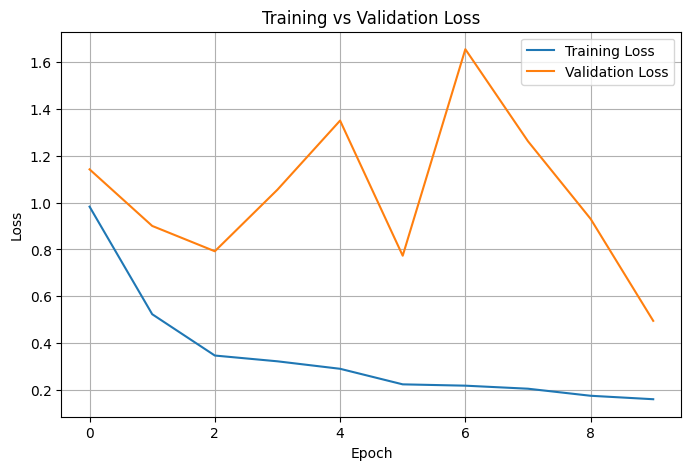

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [117]:
print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([3, 3, 320, 320])
Output shape: torch.Size([3, 7, 320, 320])


In [118]:
print("Input shape :", images.shape)
print("Output shape :", outputs.shape)

Input shape : torch.Size([3, 3, 320, 320])
Output shape : torch.Size([3, 7, 320, 320])


In [119]:
import torch.nn as nn
from segmentation_models_pytorch.losses import DiceLoss

ce_loss = nn.CrossEntropyLoss()

dice_loss = DiceLoss(
    mode="multiclass",
    from_logits=True
)

def combined_loss(pred, target):
    loss_ce = ce_loss(pred, target)
    loss_dice = dice_loss(pred, target)
    return 0.5 * loss_ce + 0.5 * loss_dice

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4
)

print("Loss and optimizer ready!")

Loss and optimizer ready!


In [120]:
NUM_EPOCHS = 1

model.train()

running_loss = 0.0

for batch_idx, (images, masks) in enumerate(train_loader):

    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()

    outputs = model(images)

    loss = combined_loss(outputs, masks)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    print(
        f"Batch [{batch_idx+1}/{len(train_loader)}] "
        f"Loss: {loss.item():.4f}"
    )

print(
    f"\n1-Epoch Training Loss: "
    f"{running_loss / len(train_loader):.4f}"
)

Batch [1/17] Loss: 0.1069
Batch [2/17] Loss: 0.1200
Batch [3/17] Loss: 0.1250
Batch [4/17] Loss: 0.1920
Batch [5/17] Loss: 0.2425
Batch [6/17] Loss: 0.1083
Batch [7/17] Loss: 0.1892
Batch [8/17] Loss: 0.1632
Batch [9/17] Loss: 0.1938
Batch [10/17] Loss: 0.1826
Batch [11/17] Loss: 0.1644
Batch [12/17] Loss: 0.0969
Batch [13/17] Loss: 0.1136
Batch [14/17] Loss: 0.2055
Batch [15/17] Loss: 0.1178
Batch [16/17] Loss: 0.1031
Batch [17/17] Loss: 0.0215

1-Epoch Training Loss: 0.1439


In [122]:
import os
import torch
import matplotlib.pyplot as plt

NUM_EPOCHS = 10

best_val_loss = float("inf")

train_losses = []
val_losses = []

os.makedirs(f"{BASE}/models", exist_ok=True)

for epoch in range(NUM_EPOCHS):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(
            outputs,
            masks
        )

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)

            loss = combined_loss(
                outputs,
                masks
            )

            running_val_loss += loss.item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            f"{BASE}/models/best_model.pth"
        )

        print("   → Best model saved!")

Epoch [1/10] Train Loss: 0.1075 | Val Loss: 0.1683
   → Best model saved!
Epoch [2/10] Train Loss: 0.1044 | Val Loss: 0.1397
   → Best model saved!
Epoch [3/10] Train Loss: 0.1755 | Val Loss: 0.1465
Epoch [4/10] Train Loss: 0.1188 | Val Loss: 0.1415
Epoch [5/10] Train Loss: 0.0938 | Val Loss: 0.1419
Epoch [6/10] Train Loss: 0.0939 | Val Loss: 0.1392
   → Best model saved!
Epoch [7/10] Train Loss: 0.0930 | Val Loss: 0.1376
   → Best model saved!
Epoch [8/10] Train Loss: 0.0868 | Val Loss: 0.1276
   → Best model saved!
Epoch [9/10] Train Loss: 0.0746 | Val Loss: 0.1343
Epoch [10/10] Train Loss: 0.0855 | Val Loss: 0.1206
   → Best model saved!


In [123]:
import torch
import numpy as np

# Load best model
model.load_state_dict(
    torch.load(
        f"{BASE}/models/best_model.pth",
        map_location=DEVICE
    )
)

model.eval()

num_classes = 7

intersection = np.zeros(num_classes)
union = np.zeros(num_classes)
dice_denominator = np.zeros(num_classes)

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        ).cpu().numpy()

        masks = masks.numpy()

        for class_id in range(num_classes):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = np.logical_and(
                pred_class,
                true_class
            ).sum()

            pred_pixels = pred_class.sum()
            true_pixels = true_class.sum()

            intersection[class_id] += inter
            union[class_id] += (
                pred_pixels +
                true_pixels -
                inter
            )

            dice_denominator[class_id] += (
                pred_pixels +
                true_pixels
            )


# Calculate metrics
dice_scores = (
    2 * intersection /
    (dice_denominator + 1e-8)
)

iou_scores = (
    intersection /
    (union + 1e-8)
)


class_names = [
    "Background",
    "Tissue folds",
    "Ink",
    "Air bubbles",
    "Dust",
    "Marker",
    "Out-of-focus"
]


print("\n===== SEGMENTATION RESULTS =====\n")

for i, name in enumerate(class_names):

    print(
        f"{name:15s} "
        f"Dice: {dice_scores[i]:.4f} | "
        f"IoU: {iou_scores[i]:.4f}"
    )


# Mean excluding background
mean_dice = dice_scores[1:].mean()
mean_iou = iou_scores[1:].mean()

print("\nMean Dice:", round(mean_dice, 4))
print("Mean IoU :", round(mean_iou, 4))


===== SEGMENTATION RESULTS =====

Background      Dice: 0.9949 | IoU: 0.9898
Tissue folds    Dice: 0.8347 | IoU: 0.7163
Ink             Dice: 0.3318 | IoU: 0.1989
Air bubbles     Dice: 0.9329 | IoU: 0.8743
Dust            Dice: 0.0000 | IoU: 0.0000
Marker          Dice: 0.8569 | IoU: 0.7497
Out-of-focus    Dice: 0.9886 | IoU: 0.9774

Mean Dice: 0.6575
Mean IoU : 0.5861


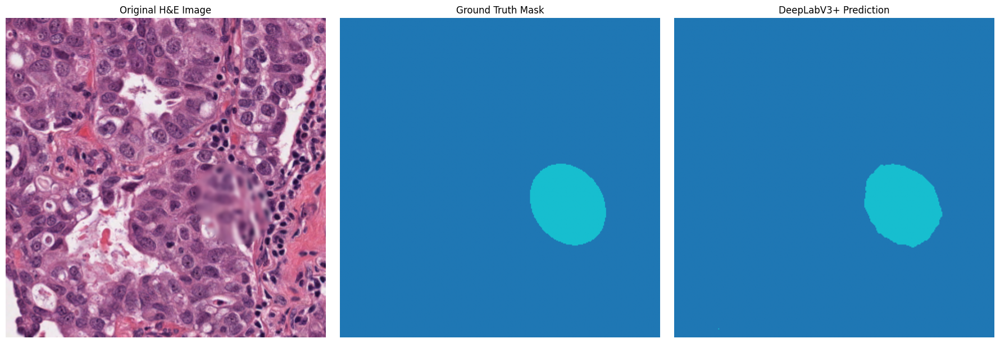

Saved: /content/WSI_Artifact_Detection/outputs/prediction_result.png


In [124]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Get one test sample
image, true_mask = test_dataset[0]

# Prepare image for model
input_image = image.unsqueeze(0).to(DEVICE)

# Prediction
model.eval()

with torch.no_grad():
    output = model(input_image)

prediction = torch.argmax(
    output,
    dim=1
).squeeze().cpu().numpy()

# Convert image CHW -> HWC
image_np = image.permute(1, 2, 0).cpu().numpy()

true_mask_np = true_mask.numpy()

# Class names
class_names = [
    "Background",
    "Tissue folds",
    "Ink",
    "Air bubbles",
    "Dust",
    "Marker",
    "Out-of-focus"
]

# Create visualization
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

# Original image
axes[0].imshow(image_np)
axes[0].set_title("Original H&E Image")
axes[0].axis("off")

# Ground truth
axes[1].imshow(
    true_mask_np,
    cmap="tab10",
    vmin=0,
    vmax=6
)
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

# Prediction
axes[2].imshow(
    prediction,
    cmap="tab10",
    vmin=0,
    vmax=6
)
axes[2].set_title("DeepLabV3+ Prediction")
axes[2].axis("off")

plt.tight_layout()

# Save for GitHub
output_path = f"{BASE}/outputs/prediction_result.png"

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

Ground truth classes: [0 6]
Predicted classes: [0 6]


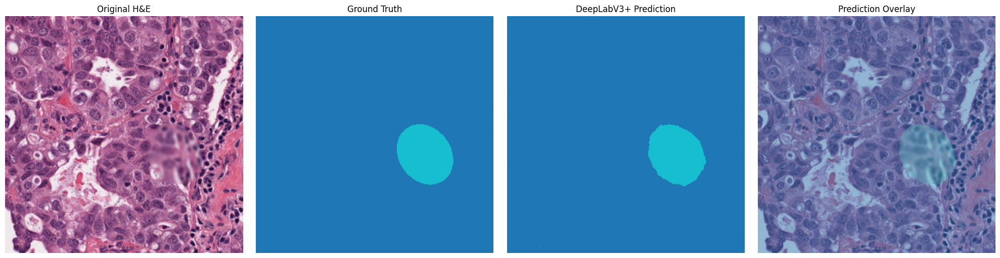

Saved: /content/WSI_Artifact_Detection/outputs/final_prediction_visualization.png


In [125]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Class information
class_names = [
    "Background",
    "Tissue folds",
    "Ink",
    "Air bubbles",
    "Dust",
    "Marker",
    "Out-of-focus"
]

# Get unique classes
print("Ground truth classes:", np.unique(true_mask_np))
print("Predicted classes:", np.unique(prediction))

# Create figure
fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 5)
)

# -------------------------
# 1. Original
# -------------------------
axes[0].imshow(image_np)
axes[0].set_title("Original H&E")
axes[0].axis("off")


# -------------------------
# 2. Ground Truth
# -------------------------
axes[1].imshow(
    true_mask_np,
    cmap="tab10",
    vmin=0,
    vmax=6
)

axes[1].set_title("Ground Truth")
axes[1].axis("off")


# -------------------------
# 3. Prediction
# -------------------------
axes[2].imshow(
    prediction,
    cmap="tab10",
    vmin=0,
    vmax=6
)

axes[2].set_title("DeepLabV3+ Prediction")
axes[2].axis("off")


# -------------------------
# 4. Overlay
# -------------------------

axes[3].imshow(image_np)

axes[3].imshow(
    prediction,
    cmap="tab10",
    vmin=0,
    vmax=6,
    alpha=0.45
)

axes[3].set_title("Prediction Overlay")
axes[3].axis("off")


plt.tight_layout()

output_path = f"{BASE}/outputs/final_prediction_visualization.png"

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

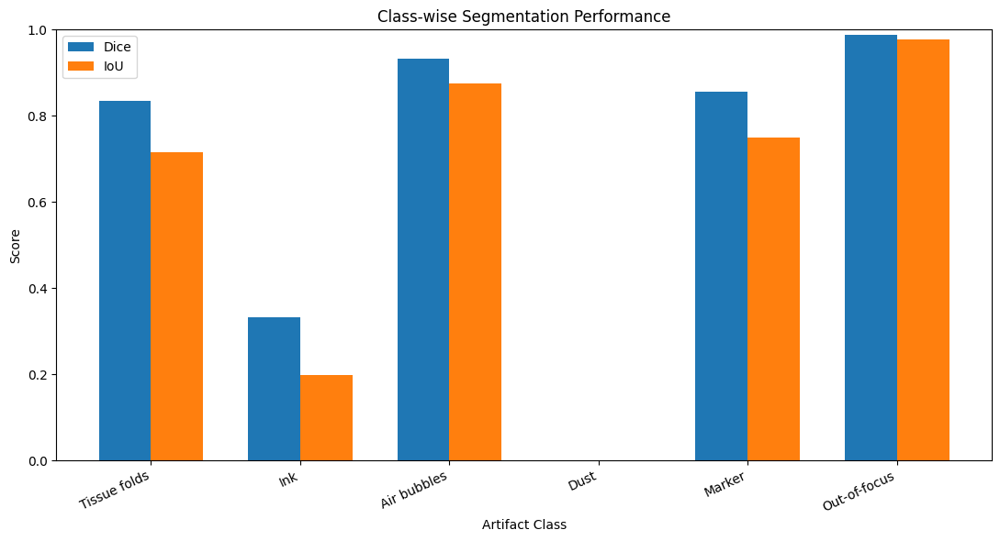

Saved: /content/WSI_Artifact_Detection/outputs/class_wise_metrics.png


In [126]:
import matplotlib.pyplot as plt
import numpy as np

artifact_names = [
    "Tissue folds",
    "Ink",
    "Air bubbles",
    "Dust",
    "Marker",
    "Out-of-focus"
]

artifact_dice = dice_scores[1:]
artifact_iou = iou_scores[1:]

x = np.arange(len(artifact_names))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width/2,
    artifact_dice,
    width,
    label="Dice"
)

plt.bar(
    x + width/2,
    artifact_iou,
    width,
    label="IoU"
)

plt.xticks(
    x,
    artifact_names,
    rotation=25,
    ha="right"
)

plt.ylabel("Score")
plt.xlabel("Artifact Class")

plt.title(
    "Class-wise Segmentation Performance"
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()

metrics_path = f"{BASE}/outputs/class_wise_metrics.png"

plt.savefig(
    metrics_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", metrics_path)

In [127]:
import pandas as pd

results_df = pd.DataFrame({
    "Class": artifact_names,
    "Dice": artifact_dice,
    "IoU": artifact_iou
})

results_df.loc[len(results_df)] = [
    "Mean",
    mean_dice,
    mean_iou
]

results_df.to_csv(
    f"{BASE}/outputs/segmentation_results.csv",
    index=False
)

results_df

,Class,Dice,IoU
0,Tissue folds,0.834687,0.716276
1,Ink,0.331754,0.198864
2,Air bubbles,0.932942,0.874312
3,Dust,0.000000,0.000000
4,Marker,0.856926,0.749667
5,Out-of-focus,0.988581,0.977419
6,Mean,0.657481,0.586090


In [128]:
import os

PROJECT = "/content/WSI_Artifact_Detection"

folders = [
    "notebooks",
    "src",
    "outputs",
    "models",
    "data"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT, folder), exist_ok=True)

print("GitHub project structure created!")

GitHub project structure created!


In [129]:
!find /content/WSI_Artifact_Detection -maxdepth 2 -type d

/content/WSI_Artifact_Detection
/content/WSI_Artifact_Detection/models
/content/WSI_Artifact_Detection/outputs
/content/WSI_Artifact_Detection/notebooks
/content/WSI_Artifact_Detection/data
/content/WSI_Artifact_Detection/data/raw
/content/WSI_Artifact_Detection/data/patches
/content/WSI_Artifact_Detection/data/train
/content/WSI_Artifact_Detection/data/test
/content/WSI_Artifact_Detection/data/val
/content/WSI_Artifact_Detection/data/monuseg
/content/WSI_Artifact_Detection/src
